In [21]:
#------------------------------------------------------------#
import numpy as np
from matplotlib import pyplot as plt
from numba import njit
import pickle
#------------------------------------------------------------#
from utils import load_data as ld
from utils import plot as pl
#------------------------------------------------------------#
from utils import topology as tp

import warnings
warnings.filterwarnings("ignore")

In [2]:
#=================================================================================================#
# Avenir font. To use it, you have to download the font-style files below.
# Comment the lines referred to fontManager if you don't need to set the font.
#from matplotlib import font_manager
#font_file   = "/home/tentori/.local/avenir_ff/AvenirLTStd-Roman.otf"
#font_file_b = "/home/tentori/.local/avenir_ff/AvenirLTStd-Black.otf"
#font_file_c = "/home/tentori/.local/avenir_ff/AvenirLTStd-Book.otf"
#font_manager.fontManager.addfont(font_file)
#font_manager.fontManager.addfont(font_file_b)
#font_manager.fontManager.addfont(font_file_c)
#------------------------------------------------------------#
#rcParams['font.family']  = "Avenir LT Std"
#rcParams['pdf.fonttype'] = 42
#rcParams['ps.fonttype']  = 42
#------------------------------------------------------------#
DIM = 25
from matplotlib import font_manager, rcParams
plt.rcParams.update({'font.size': DIM,'axes.labelsize': DIM,'axes.titlesize': DIM,'xtick.labelsize': DIM,'ytick.labelsize': DIM})
#=================================================================================================#
# Colors
colorz    = ['#255D93','#5FA6D6','#B02106','#F24D33','#2C2C2C','#787878']
#------------------------------------------------------------#
show_plot   = True
#------------------------------------------------------------#
from cmap import Colormap
def Cmap(cmap):
    return Colormap(cmap).to_mpl()
#------------------------------------------------------------#
def truncate_cmap(cmap, minval=0.0, maxval=0.8, n=256):
    from matplotlib.colors import Normalize, LinearSegmentedColormap
    return LinearSegmentedColormap.from_list( f'{cmap.name}_trunc', cmap(np.linspace(minval, maxval, n)) )
#------------------------------------------------------------#
def discrete_cmap(cmap_name='turbo', num_colors=25, minval=0., maxval=1):
    from matplotlib.colors import ListedColormap
    base = truncate_cmap(plt.get_cmap(cmap_name), minval=minval, maxval=maxval)
    return ListedColormap(base(np.linspace(0, 1, num_colors)))
#=================================================================================================#
# to create folder
def Set_Dir_Plots(path):
    import os
    if not os.path.exists(path):
        os.mkdir(path)
#=================================================================================================#

# 0. Network features

In [30]:
#=================================================================================================#
# FEATURES

modules      = '2'       # (str)   change in '2' if you want a modular net with 2 clusters
dist_rule    = 'EDR'     # (str)
nNeurons     = 1000      # number of neurons
local_II     = False     # set True if you want I–>I links  
deltat       = 1
network_load = False     # set True to upload already generated networks

#=================================================================================================#
# folder to store data, specifying: nNeurons, modules and dist_rule

if local_II==True:
    folder       = f'network{nNeurons}_{modules}mod_{dist_rule}_II/'
else:
    folder       = f'network{nNeurons}_{modules}mod_{dist_rule}_noII/'

In [31]:
#=================================================================================================#
# data generation paths

path_results = './'
path_out     = path_results+'Generated_network/'+folder
path_data    = path_out+'Data/'
path_params  = path_data+'Parameters/'
path_imgs    = path_data+'Plots/'

#------------------------------------------------------------#
# create folders

Set_Dir_Plots(path_results)
Set_Dir_Plots(path_results+'Generated_network/')
Set_Dir_Plots(path_out)
Set_Dir_Plots(path_data)
Set_Dir_Plots(path_params)
Set_Dir_Plots(path_imgs)

#--------------------------------------------------------#
# empirical topology (for case modules='2')



###  A A A !  download Cult.mat to gen a 2 modules network    A A A ! ###



# main_path: here put the path where you stored Cult.mat 
# (empirical data from a culture with 2 spatial clusters)
# download Cult.mat from here: https://github.com/elisatentori/causality/tree/main/Data_MaxOne/Culture1REC1/Data
main_path    = '/home/tentori/experimental_works/causality/Original_data/Causality/' 
sim_folder   = 'Culture1REC1/'
deltat = 1
#=================================================================================================#

# 1. Network

## 1.1 Build network map (2 modules or just 1)

In [32]:
if modules == '2':
    #=================================================================================================#
    # EMPIRICAL BASED MAP (2 modules)
    #------------------------------------------------------------#
    # loading empirical map features
    _, channel, _, pos, cluster, _, _, rate = ld.load_original_data(main_path, sim_folder, file='Cult.mat')
    channel = channel - 1
    cluster = tp._reorder_clusters_by_x(pos, cluster)
    # subsample channels with max rate for each group/cluster of channels
    sub_idx = tp._subsample_indices(channel, cluster, rate)
    #------------------------------------------------------------#    
    samples_orig  = pos[sub_idx,:]/1000
    samples_added = tp.add_nearby_points(samples_orig, n_new=nNeurons-samples_orig.shape[0], scale=0.05)
    samples       = np.vstack([samples_orig,samples_added])
    
    # I add these 6 other positions to guarantee that, after generating the network adj matrix (see below)
    # the 2 clusters are connected.
    samples[0,0]  = 2.60;  samples[0,1]  = 0.2
    samples[1,0]  = 2.49;  samples[1,1]  = 0.15
    samples[2,0]  = 2.42;  samples[2,1]  = 0.10
    samples[2,0]  = 2.35;  samples[2,1]  = 0.05
    samples[2,0]  = 2.30;  samples[2,1]  = 0.08
    samples[3,0]  = 2.25;  samples[3,1]  = 0.15
    L       = np.argsort(samples[:,0])
    samples = samples[L,:] # sort by x-axis
    del channel, pos, cluster, sub_idx, samples_orig, samples_added, L
    
elif modules == '1':
    #=================================================================================================#
    # GENERATED MAP uniform random map
    # generate random 2D map uniformly distributed, with Poisson disk sampling
    samples, r_min_used = tp.poisson_disk_until_n(x_min=0.0, x_max=3.8/4*3, y_min=0.0, y_max=2.1/4*3, n_points=nNeurons)
    print(f"Generated {len(samples)} points, with r_min = {r_min_used:.4f}")
    L       = np.argsort(samples[:,0])  # sort by x-axis
    samples = samples[L,:]
    del r_min_used, L
    

### 1.2 from nodes positions: add randomly network type (E/I) and build an adjacency matrix following an Exponential Distance Rule (EDR)

NOTE: 

- II links can be turned on/off with the variable local_II (if 0: no II links – if 1: II links)

- inhibitory neurons: 2 types FS, LTS

- I–>E links are local: r_IE is the cutoff radius which controls util wich distance links are allowed

To change the topology, you can play with parameters tp.EDR_Connections_clean.
<br>


In [33]:
if network_load==False:
    
    # ------------------------------------------------------------------------------------------------------------#
    # network dictionary
    net = { }
    
    net['neurons'] = len(samples)                # number of neurons
    net['pos']     = samples                     # neuron positions
    net['channel'] = np.arange(len(samples))     # neuron IDs
    net['modules'] = np.zeros(net['neurons'])    # module IDs
    if modules=='2':
        net['modules'][net['pos'][:,0]>2.4]=1    # tag to recognize which node belongs to which cluster
    
    # neuron types and connectivity parameters
    net['rho']     = 0.8                         # fraction of excitatoy/inhibitory neurons
                                                 # if you need a network of E neurons only, put rho to 1
    net['ntypes']  = np.random.rand(net['neurons']) < net['rho']  # boolean array
    exc_idx        = np.where(net['ntypes'])[0]
    inh_idx        = np.where(~net['ntypes'])[0]
    
    # set parameters
    # pay attention: these random numbers decide the izhikevic parameters of each neuron. 
    #                It has to be the same for all simulations based on the same exact topology
    #net['nrands']   = np.random.rand(net['neurons'])      # random numbers for model parameters    #np.random.seed(None)
    net['nrands'] = np.zeros(nNeurons)
    # excitatory nrands : random numbers betw 0 and 1
    net['nrands'][exc_idx] = np.random.rand(exc_idx.size)
    # inhibitory nrands : FS=0, LTS=1 randomly chosen among inh_idxs
    p_FS   = 0.75    # % FS
    p_LTS  = 1-p_FS  # % LTS
    n_inh  = inh_idx.size
    n_FS   = int(np.round(p_FS * n_inh))
    labels = np.array([0]*n_FS + [1]*(n_inh-n_FS))
    np.random.shuffle(labels)
    net['nrands'][inh_idx] = labels
    
    #----------------------------------------------------------------------------------------------------------------#
    # adjacency mat
    net['w_mean_exc']  = 6.0; net['w_mean_inh']  = 5.0    
    W, dist_mat = tp.EDR_Connections_clean(samples, net, p0_E=0.65, L_E=0.155, c_E=0.0, r_IE=0.18, p_FS2E=0.75, p_LTS2E=0.75, 
                                      r_II=0.18, p_FS2FS=0.75, p_LTS2LTS=0.35, local_II=local_II, LTS_th=0.75,  
                                      W_decay_exc=1.5, W_decay_inh=1.0, cv_exc=0.35, cv_inh=0.2, seed=None) 
    net['weights']       = W

    # distance matrix
    net['dist_matrix']   = dist_mat
    
    #================================================================================================================#
    #                                                DATA SAVE
    # save the network
    with open(path_data+'net.pkl', 'wb') as file:
        pickle.dump(net, file)

else:
    # data load
    with open(path_data+'net.pkl', 'rb') as file:
        net = pickle.load(file)
    deltat   = 1#net['deltat']
    samples  = net['pos']
    W        = net['weights']
    dist_mat = net['dist_matrix']


# 2. Plot network

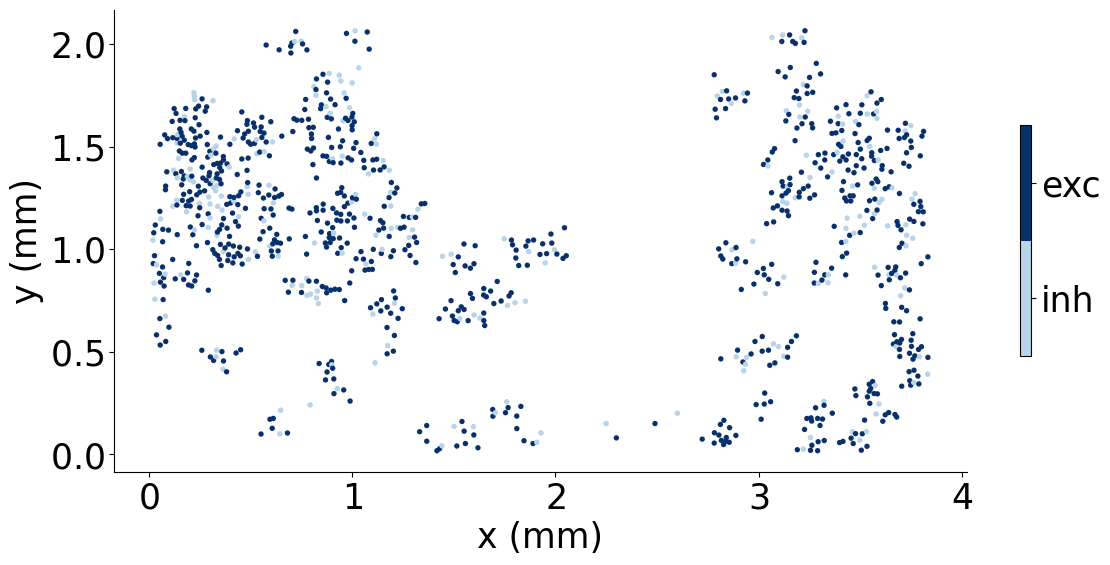

In [34]:
cmap2 = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
dotsize= 15
# FULL MAP OF CHANNELS 
x = samples[:, 0]
y = samples[:, 1]

fig, ax = plt.subplots(figsize=(13.75, 6))
scatter = ax.scatter(x, y, s=dotsize, marker='o', edgecolor='gray', linewidths=0.01, c=net['ntypes'], cmap=cmap2, zorder=0)

ax.set_xlabel('x (mm)', fontsize=DIM);    ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
cbar = fig.colorbar(scatter,ax=ax,shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])

plt.savefig(path_imgs + 'map_neus.pdf', bbox_inches='tight')


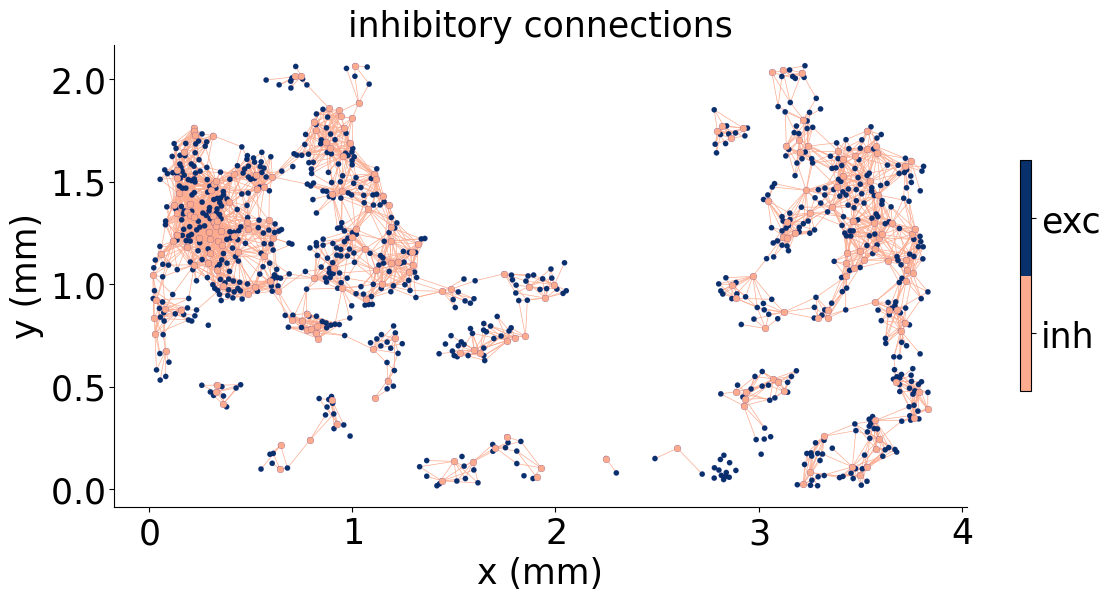

In [45]:
# (optional alt by sign, if you prefer sign-based split)
W_pos = np.where(W > 0.0, W, 0.0)   # "excitatory" by sign
W_neg = np.where(W < 0.0, W, 0.0)   # "inhibitory" by sign

#---------------------------------------------------------------------------------------------------#
# PLOT: neurons map - I connections

if modules=='2':
    edgecolor='darkblue'
    dotsize_E=15
    dotsize=25
else:
    edgecolor='darkblue'
    dotsize_E=20
    dotsize=40
    
# FULL MAP OF CHANNELS + INH CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))
# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]

# Plot neurons
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
cmap.colors[0] = cmapR.colors[0]
scatter = ax.scatter(x, y, s=dotsize_E, marker='o', edgecolor=edgecolor, linewidths=0.1, c=net['ntypes'], cmap=cmap, zorder=2)
ax.scatter(x[net['ntypes']==False], y[net['ntypes']==False], s=dotsize, marker='o', edgecolor=edgecolor, linewidths=0.1, c=cmap.colors[0], zorder=2)

# neurond n. (NxN)
rows, cols = np.nonzero(W_neg)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color=cmap.colors[0], alpha=1, lw=.5, zorder=1)
    #ax.plot([x[j], x[i]], [y[j], y[i]], color='darkblue', alpha=0.8, lw=.15, zorder=1)
ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
ax.set_title('inhibitory connections')
plt.savefig(path_imgs + 'connectivity_neurons_map_Ilinks.pdf', bbox_inches='tight')
if show_plot==False:
    plt.close()

In [36]:
cmapR   = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
cmap2   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmap2.colors[0] = cmapR.colors[0]

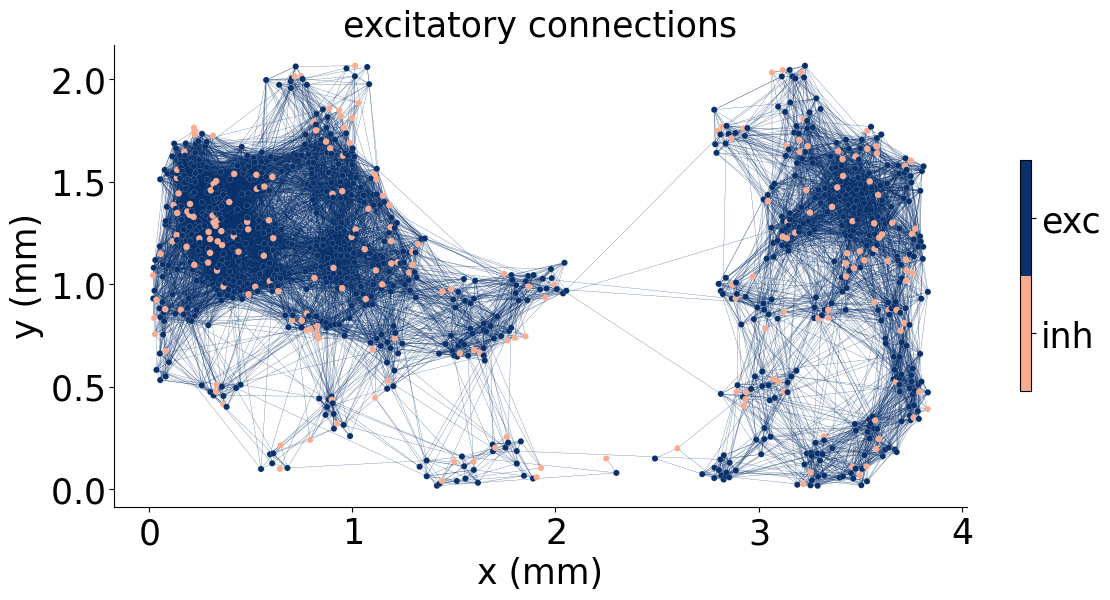

In [37]:
#---------------------------------------------------------------------------------------------------#
# PLOT: neurons map - E connections

if modules=='2':
    edgecolor='white'
    dotsize=20
else:
    edgecolor='white'
    dotsize=40

# FULL MAP OF CHANNELS + EXC CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))
# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]
# Plot neurons
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
cmap.colors[0] = cmapR.colors[0]
scatter = ax.scatter(x, y, s=dotsize, marker='o', edgecolor=edgecolor, linewidths=0.1, c=net['ntypes'], cmap=cmap, zorder=2)

# existing connections (W ≠ 0)
rows, cols = np.nonzero(W_pos)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color=cmap.colors[1], alpha=0.8, lw=.2, zorder=0)
ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
ax.set_title('excitatory connections')
plt.savefig(path_imgs + 'connectivity_neurons_map_Elinks.pdf', bbox_inches='tight')
if show_plot==False:
    plt.close()
#---------------------------------------------------------------------------------------------------#


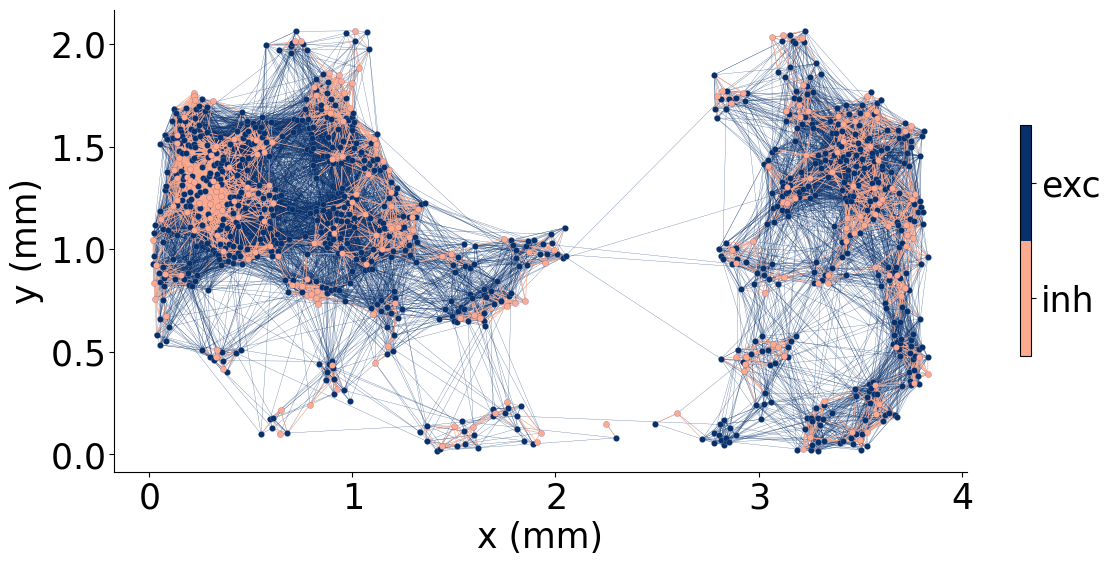

In [38]:
# FULL MAP OF CHANNELS + CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))

# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]

if modules=='2':
    edgecolor='white'
    dotsize=20
else:
    edgecolor='darkblue'
    dotsize=30
    
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
cmap.colors[0] = cmapR.colors[0]

# Plot neurons
scatter = ax.scatter(x, y, s=dotsize-10, marker='o', edgecolor=edgecolor, linewidths=0.1, c=net['ntypes'], cmap=cmap, zorder=2)
ax.scatter(x[net['ntypes']==True], y[net['ntypes']==True], s=dotsize, marker='o', edgecolor='white', linewidths=0.1, c=cmap.colors[1], cmap=cmap, zorder=3)
ax.scatter(x[net['ntypes']==False], y[net['ntypes']==False], s=dotsize, marker='o', edgecolor='darkblue', linewidths=0.1, c=cmap.colors[0], cmap=cmap, zorder=3)
# neurond n. (NxN)
N = W.shape[0]

# existing connections (W ≠ 0)
'''rows, cols = np.nonzero(W)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.4, lw=.1, zorder=0)
'''
rows, cols = np.nonzero(W_pos)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color=cmap.colors[1], alpha=0.8, lw=.2, zorder=0)
rows, cols = np.nonzero(W_neg)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color=cmap.colors[0], alpha=1, lw=.5, zorder=1)

ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
plt.savefig(path_imgs + 'connectivity_neurons_map.pdf', bbox_inches='tight')


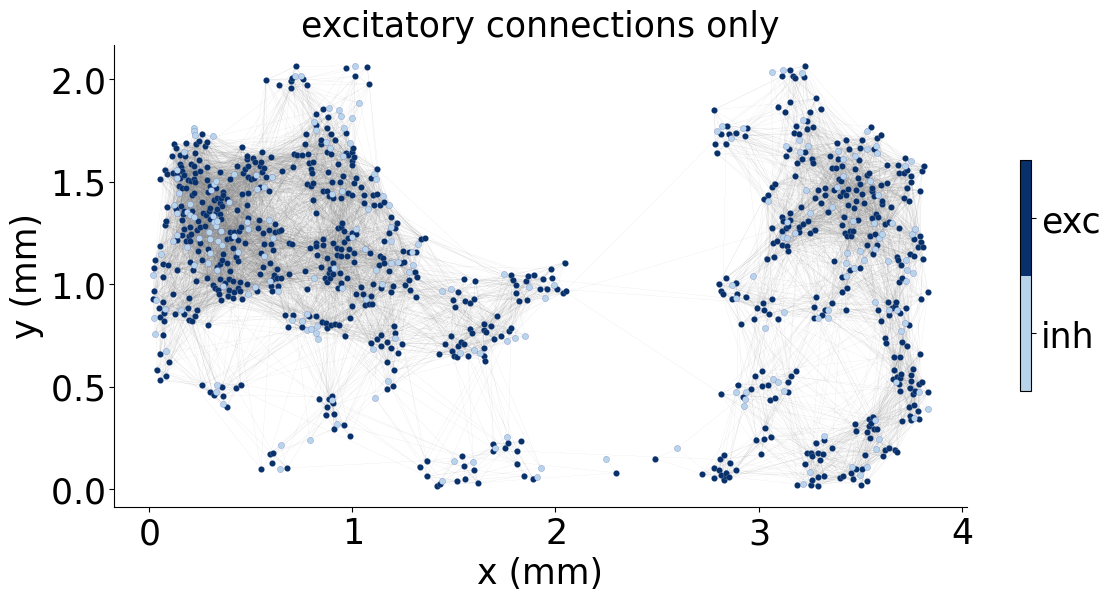

In [46]:
# FULL MAP OF CHANNELS + CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))

# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]

if modules=='2':
    edgecolor='white'
    dotsize=20
else:
    edgecolor='darkblue'
    dotsize=30
    
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
#cmap.colors[0] = cmapR.colors[0]

# Plot neurons
scatter = ax.scatter(x, y, s=dotsize-10, marker='o', edgecolor=edgecolor, linewidths=0.1, c=net['ntypes'], cmap=cmap, zorder=2)
ax.scatter(x[net['ntypes']==True], y[net['ntypes']==True], s=dotsize, marker='o', edgecolor='white', linewidths=0.1, c=cmap.colors[1], cmap=cmap, zorder=3)
ax.scatter(x[net['ntypes']==False], y[net['ntypes']==False], s=dotsize, marker='o', edgecolor='darkblue', linewidths=0.1, c=cmap.colors[0], cmap=cmap, zorder=3)
# neurond n. (NxN)
N = W.shape[0]

# existing connections (W ≠ 0)

rows, cols = np.nonzero(W_pos)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.4, lw=.1, zorder=0)
#rows, cols = np.nonzero(W_neg)
#for i, j in zip(rows, cols):
#    ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.4, lw=.1, zorder=0)

ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
ax.set_title('excitatory connections only')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
plt.savefig(path_imgs + '_map_E_to_all.pdf', bbox_inches='tight')


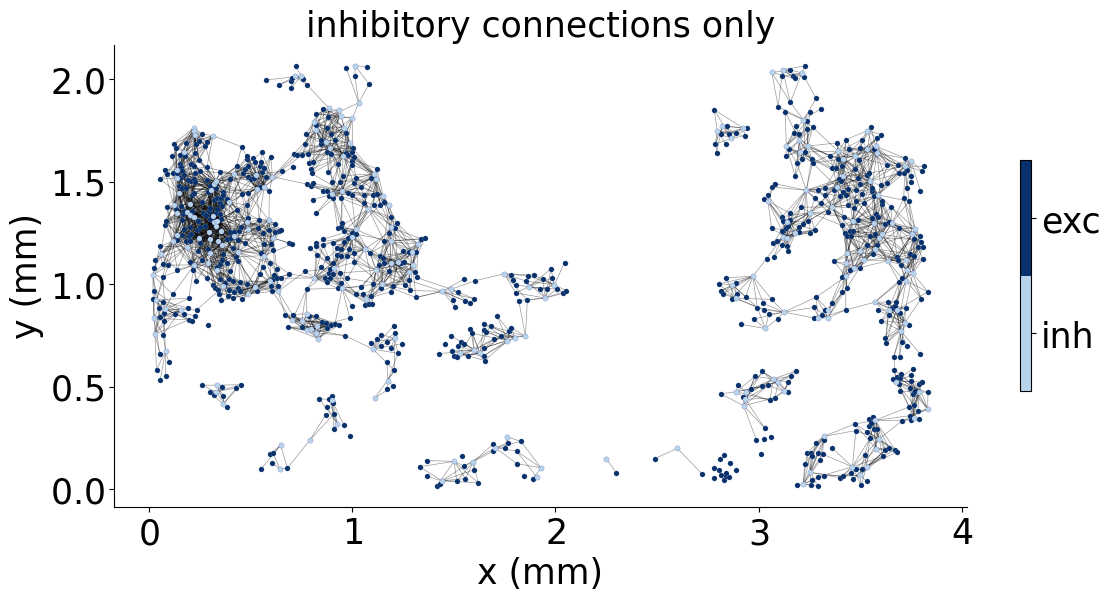

In [40]:
# FULL MAP OF CHANNELS + CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))

# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]

if modules=='2':
    edgecolor='white'
    dotsize=15
else:
    edgecolor='darkblue'
    dotsize=20
    
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
#cmap.colors[0] = cmapR.colors[0]

# Plot neurons
scatter = ax.scatter(x, y, s=dotsize-10, marker='o', edgecolor=edgecolor, linewidths=0.1, c=net['ntypes'], cmap=cmap, zorder=2)
ax.scatter(x[net['ntypes']==True], y[net['ntypes']==True], s=dotsize, marker='o', edgecolor='white', linewidths=0.1, c=cmap.colors[1], cmap=cmap, zorder=3)
ax.scatter(x[net['ntypes']==False], y[net['ntypes']==False], s=dotsize, marker='o', edgecolor='darkblue', linewidths=0.1, c=cmap.colors[0], cmap=cmap, zorder=3)
# neurond n. (NxN)
N = W.shape[0]

# existing connections (W ≠ 0)

#rows, cols = np.nonzero(W_pos)
#for i, j in zip(rows, cols):
#    ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.4, lw=.1, zorder=0)
rows, cols = np.nonzero(W_neg)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color='k', alpha=0.4, lw=.5, zorder=0)

ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
ax.set_title('inhibitory connections only')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
plt.savefig(path_imgs + '_map_I_to_all.pdf', bbox_inches='tight')


# Another option to gen a modular network

In [61]:
samples1, r_min_used = tp.poisson_disk_until_n(x_min=0.0, x_max=3.8/4*3, y_min=0.0, y_max=2.1/4*3, n_points=500)
samples1[:,0] = samples1[:,0]+5
samples1[:,1] = samples1[:,1]+1

samples2, r_min_used = tp.poisson_disk_until_n(x_min=0.0, x_max=3.8/4*3, y_min=0.0, y_max=2.1/4*3, n_points=500)

samples = np.vstack([samples1,samples2])
print(samples.shape,samples1.shape,samples2.shape)

print(f"Generated {len(samples)} points, with r_min = {r_min_used:.4f}")
L       = np.argsort(samples[:,0])  # sort by x-axis
samples = samples[L,:]

(1000, 2) (500, 2) (500, 2)
Generated 1000 points, with r_min = 0.0735


In [62]:


# ------------------------------------------------------------------------------------------------------------#
# network dictionary
net = { }

net['neurons'] = len(samples)                # number of neurons
net['pos']     = samples                     # neuron positions
net['channel'] = np.arange(len(samples))     # neuron IDs
net['modules'] = np.zeros(net['neurons'])    # module IDs
if modules=='2':
    net['modules'][net['pos'][:,0]>2.4]=1    # tag to recognize which node belongs to which cluster

# neuron types and connectivity parameters
net['rho']     = 0.8                         # fraction of excitatoy/inhibitory neurons
                                             # if you need a network of E neurons only, put rho to 1
net['ntypes']  = np.random.rand(net['neurons']) < net['rho']  # boolean array
exc_idx        = np.where(net['ntypes'])[0]
inh_idx        = np.where(~net['ntypes'])[0]

# set parameters
# pay attention: these random numbers decide the izhikevic parameters of each neuron. 
#                It has to be the same for all simulations based on the same exact topology
#net['nrands']   = np.random.rand(net['neurons'])      # random numbers for model parameters    #np.random.seed(None)
net['nrands'] = np.zeros(nNeurons)
# excitatory nrands : random numbers betw 0 and 1
net['nrands'][exc_idx] = np.random.rand(exc_idx.size)
# inhibitory nrands : FS=0, LTS=1 randomly chosen among inh_idxs
p_FS   = 0.75    # % FS
p_LTS  = 1-p_FS  # % LTS
n_inh  = inh_idx.size
n_FS   = int(np.round(p_FS * n_inh))
labels = np.array([0]*n_FS + [1]*(n_inh-n_FS))
np.random.shuffle(labels)
net['nrands'][inh_idx] = labels

#----------------------------------------------------------------------------------------------------------------#
# adjacency mat
net['w_mean_exc']  = 6.0; net['w_mean_inh']  = 5.0    
W, dist_mat = tp.EDR_Connections_clean(samples, net, p0_E=0.65, L_E=0.155, c_E=0.0, r_IE=0.18, p_FS2E=0.75, p_LTS2E=0.75, 
                                  r_II=0.18, p_FS2FS=0.75, p_LTS2LTS=0.35, local_II=local_II, LTS_th=0.75,  
                                  W_decay_exc=1.5, W_decay_inh=1.0, cv_exc=0.35, cv_inh=0.2, seed=None) 
net['weights']       = W

# distance matrix
net['dist_matrix']   = dist_mat



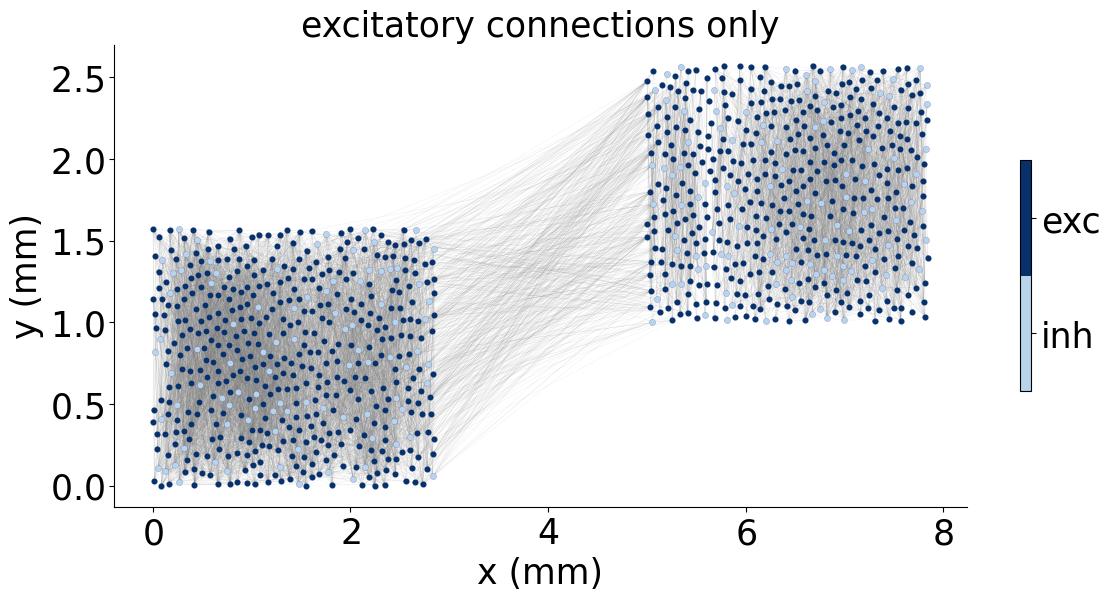

In [63]:
# FULL MAP OF CHANNELS + CONNECTIONS
fig, ax = plt.subplots(figsize=(13.75, 6))

# Neuron coordinates
x = samples[:, 0]
y = samples[:, 1]

if modules=='2':
    edgecolor='white'
    dotsize=20
else:
    edgecolor='darkblue'
    dotsize=30
    
cmap   = discrete_cmap('Blues', 2, minval=0.3, maxval=1)
cmapR  = discrete_cmap('Reds', 2, minval=0.3, maxval=1)
#cmap.colors[0] = cmapR.colors[0]

# Plot neurons
scatter = ax.scatter(x, y, s=dotsize-10, marker='o', edgecolor=edgecolor, linewidths=0.1, c=net['ntypes'], cmap=cmap, zorder=2)
ax.scatter(x[net['ntypes']==True], y[net['ntypes']==True], s=dotsize, marker='o', edgecolor='white', linewidths=0.1, c=cmap.colors[1], cmap=cmap, zorder=3)
ax.scatter(x[net['ntypes']==False], y[net['ntypes']==False], s=dotsize, marker='o', edgecolor='darkblue', linewidths=0.1, c=cmap.colors[0], cmap=cmap, zorder=3)
# neurond n. (NxN)
N = W.shape[0]

# existing connections (W ≠ 0)

rows, cols = np.nonzero(W_pos)
for i, j in zip(rows, cols):
    ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.4, lw=.1, zorder=0)
#rows, cols = np.nonzero(W_neg)
#for i, j in zip(rows, cols):
#    ax.plot([x[j], x[i]], [y[j], y[i]], color='gray', alpha=0.4, lw=.1, zorder=0)

ax.set_xlabel('x (mm)', fontsize=DIM)
ax.set_ylabel('y (mm)', fontsize=DIM)
pl.set_format(ax, axis_ticks='both', cbar=None, DIM=DIM)
ax.set_title('excitatory connections only')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['inh', 'exc'])
#plt.savefig(path_imgs + '_map_E_to_all.pdf', bbox_inches='tight')
